# 🗑️ Marine Pollution Object Detection 🤖
Please check `READ.ME` file for prerequisite installations before continuing

## 🌱 Preparing the Environment

In [17]:
# Run GPU acceleration if available
import torch

print("ROCm / CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))


ROCm / CUDA Available: True
GPU Device Name: AMD Radeon RX 7700 XT


## 🗂️ Loading the Dataset
The dataset includes `189` images, annotated in `YOLOv11` format.
  
The `7` types of classification include:
1. Bottle Cap
2. Cone Cap
3. Leaf
4. Netting
5. Plastic Bag
6. Plastic Strand
7. Sponge

Dataset was <font color='#FFC067'>split</font> and <font color='#FFC067'>pre-processed</font> for consistency using `Roboflow`:
1. Auto-orientation of pixel data (with EXIF-orientation stripping)  
2. Resized to `512x512` (Stretch)
  


### 📢Note‼️
* Running the subparts below are not required if you directly downloaded `Trash-Tank-YOLOv11.zip` and do not want to use a database. 

### Part 1: 💾 Importing from Roboflow
* Replace `ROBOFLOW_API_KEY` with your own in `.env`
* Data is already divided into training, validation, and test sets
* Check for correct dataset path

In [1]:
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()

rf_key = os.getenv('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=rf_key)

project = rf.workspace('brittany-nguyen').project('trash-tank-yolov11')
version = project.version(4)
dataset = version.download('yolov11')

loading Roboflow workspace...
loading Roboflow project...


In [19]:
# Verify dataset path
try:
    dataset_path = dataset.location
    print(f"Files in {os.path.basename(dataset_path)}: {os.listdir(dataset_path)}")

    # Set file necessary file paths
    train_path = os.path.join(dataset_path, 'train/')
    val_path = os.path.join(dataset_path, 'valid/')
    test_path = os.path.join(dataset_path, 'test/')
    yaml_path = os.path.join(dataset_path, 'data.yaml')

    print("All paths are set successfully!")

except Exception as e:
    print(f"\nUnable to locate file path. Error details:\n{e}")

Files in Trash-Tank-YOLOv11-4: ['data.yaml', 'README.roboflow.txt', 'valid', 'README.dataset.txt', 'train', 'test']
All paths are set successfully!


### Part 2: 🔌 Connecting to the DATABASE
Configure the following parameters in `env`:
* `DRIVER`: Specify the exact driver software name 
* `SERVER`: Use network name or IP address of the machine
* `DATABASE`: Choose the specific database for the project
    * e.g. Create a database inside `master` 
* Choose your usual authentication used to access the database



In [18]:
# Connect to SQL Server database
import pyodbc
import os 
from dotenv import load_dotenv

load_dotenv()

db_server = os.getenv('DB_SERVER')
db_username = os.getenv('DB_USERNAME')
db_password = os.getenv('DB_PASSWORD')

try:
    conn_str = (
        "DRIVER={ODBC Driver 18 for SQL Server};"
        f"SERVER={db_server};"
        "DATABASE=MarinePollutionDB;"
        f"UID={db_username};" 
        f"PWD={db_password};" 
        "TrustServerCertificate=yes;"
    )

    conn = pyodbc.connect(conn_str)
    cursor = conn.cursor()
    print("Successfully connected to the database!\n")

    
except Exception as e:
    print(f"\nConnection failed. Error details:\n{e}")


Successfully connected to the database!



### Part 3: 🛢️ Initializing Schema Infrastructure
* Uses the script `db.py` and `schema.sql` to create tables and store procedures
* Please ensureall metadata are loaded corectly


In [4]:
from db import initialize_schema

# Create schema infrastructure
initialize_schema(cursor)
conn.commit()

Schema infrastracture created.


### Part 4: 📦 Storing Image and Label Annotations
* Refer to `README.md` or `ERD.png` for database architecture
* Convert `dataset.yaml` for `classId` and `className`
* Use stored procedures to load all image data

In [5]:
from db import load_class

# Load classes into the database
load_class(cursor, yaml_path)
conn.commit()

Classes loaded successfully.


In [6]:
from db import load_dataset

# Load dataset into the database
load_dataset(cursor, dataset_path)
conn.commit()

189 images already present in the database.
No new images to insert.


In [10]:
# Disconnect from the database
cursor.close()
conn.close()
print("\nDisconnected from the database!")


Disconnected from the database!


In [ ]:
import os

all_new_files = []
for root, _, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_new_files.append(os.path.join(root, f))

print(f"Found {len(all_new_files)} files")

import time

# Linear duplicate check per new file
start = time.time()
seen = []
for f in all_new_files:
    if f not in seen:  # O(n) scan each time
        seen.append(f)
naive_curation_time = time.time() - start

# SQL batch insert 
splitID = 0
imageRows = [(f, splitID) for f in all_new_files]
cursor.fast_executemany = True

start = time.time()
cursor.executemany(
    "INSERT INTO Image (filePath, splitID) VALUES (?, ?)",
    imageRows
)
cursor.connection.commit()
sql_curation_time = time.time() - start

pct = ((naive_curation_time - sql_curation_time) / naive_curation_time) * 100
print(f"Curation time improvement: {pct:.1f}%")

Found 189 files
Prepared 189 rows for insert
Curation time improvement: -27176.1%


## 🚀 Initializing TensorBoard
TensorBoard is a <font color='#FFC067'>visualization tool</font> for real-time insights of the training model:
* Monitors key metrics (e.g. loss, accuracy, and learning rates)
* Adjusts in real-time and improves overall model performance
* Showcases possible overfitting or underfitting cases

Note: <font color='#FFC067'>Frequently refresh</font> the button in the top right of the TensorBoard.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/detect/train

## 🎯 Training the YOLOv11 Model
Key Training Parameters:
* `imgsz` defines the <font color='#FFC067'>target image size</font> of the inputs for consistency
* `batch` processes the <font color='#FFC067'>number of images</font> concurrently  
* `epochs` establish the <font color='#FFC067'>number of complete cycles</font> for training

Note: It is important to check the accuracy, find class weaknesses, and track improvements within the model.
  

In [12]:
from ultralytics import YOLO

# Load YOLOv11 model
model = YOLO('yolo11n.pt')

# Set dataset configuration to YAML file
dataset_config = os.path.join(dataset_path, 'data.yaml') # Load all class labels

# Train the model
results = model.train(
    data=dataset_config,
    epochs=100,
    batch=64,  # Set appropriate batch size
    imgsz=640,  # Standardize image size for training
    plots=True,
    patience=50
)

# Inspect training results
print(results)

New https://pypi.org/project/ultralytics/8.4.138 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.126 🚀 Python-3.12.3 torch-2.11.0+rocm7.2 CUDA:0 (AMD Radeon RX 7700 XT, 12081MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/brittnyn/marine_pollution_object_detection_yolo_v11/Trash-Tank-YOLOv11-4/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=

## 📊 Evaluating the Model
* Use validation data and metrics to evaluate the model performance

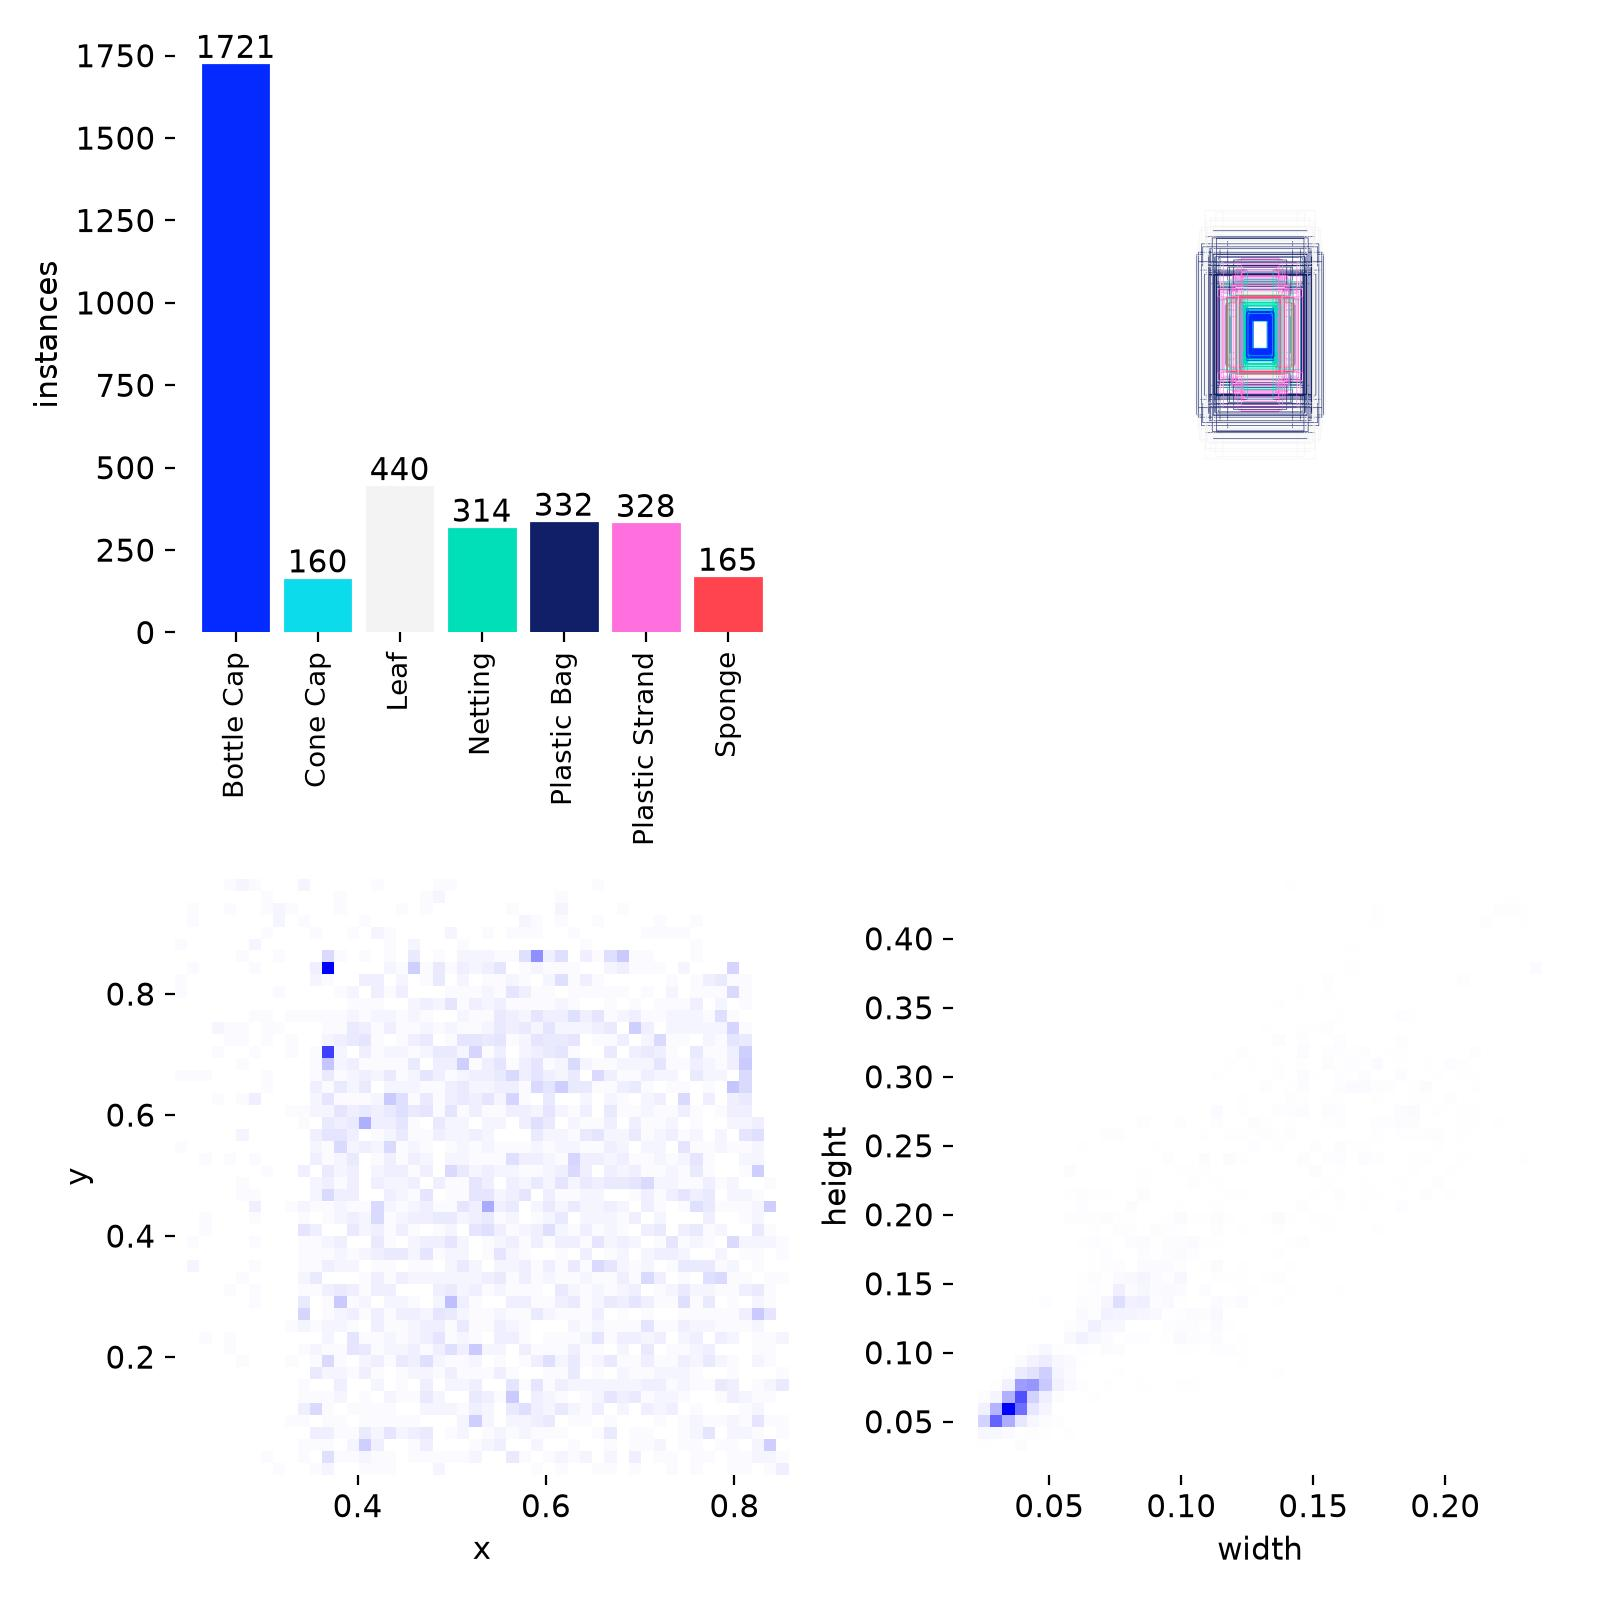

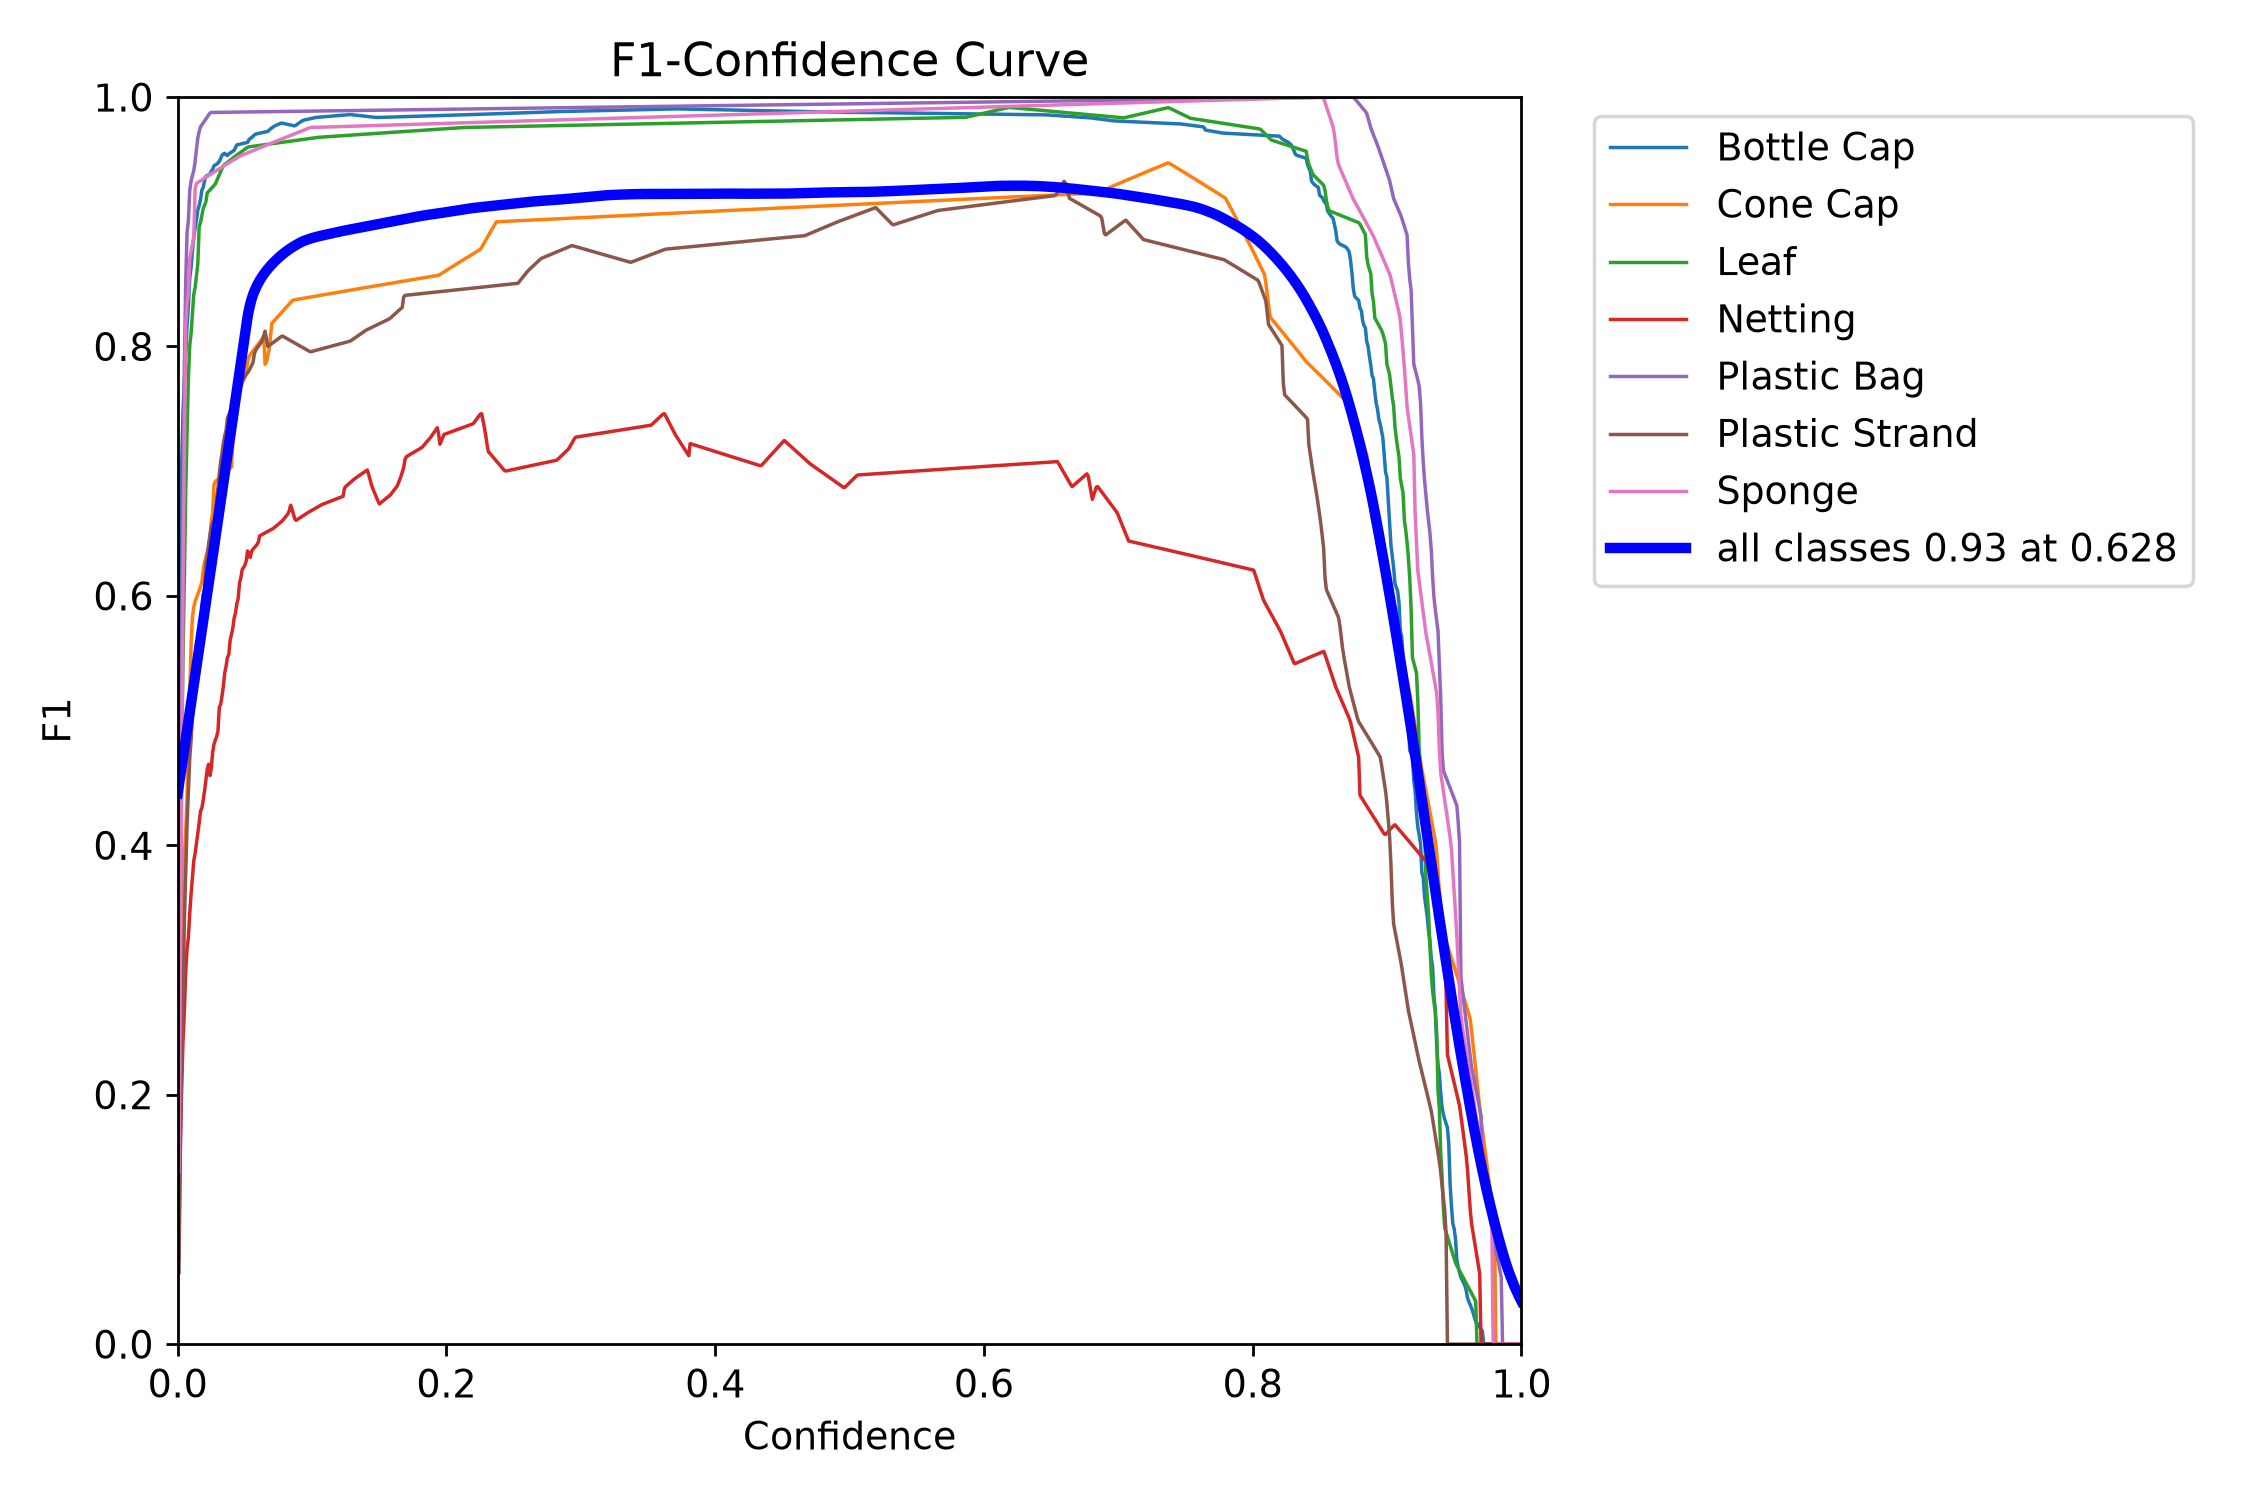

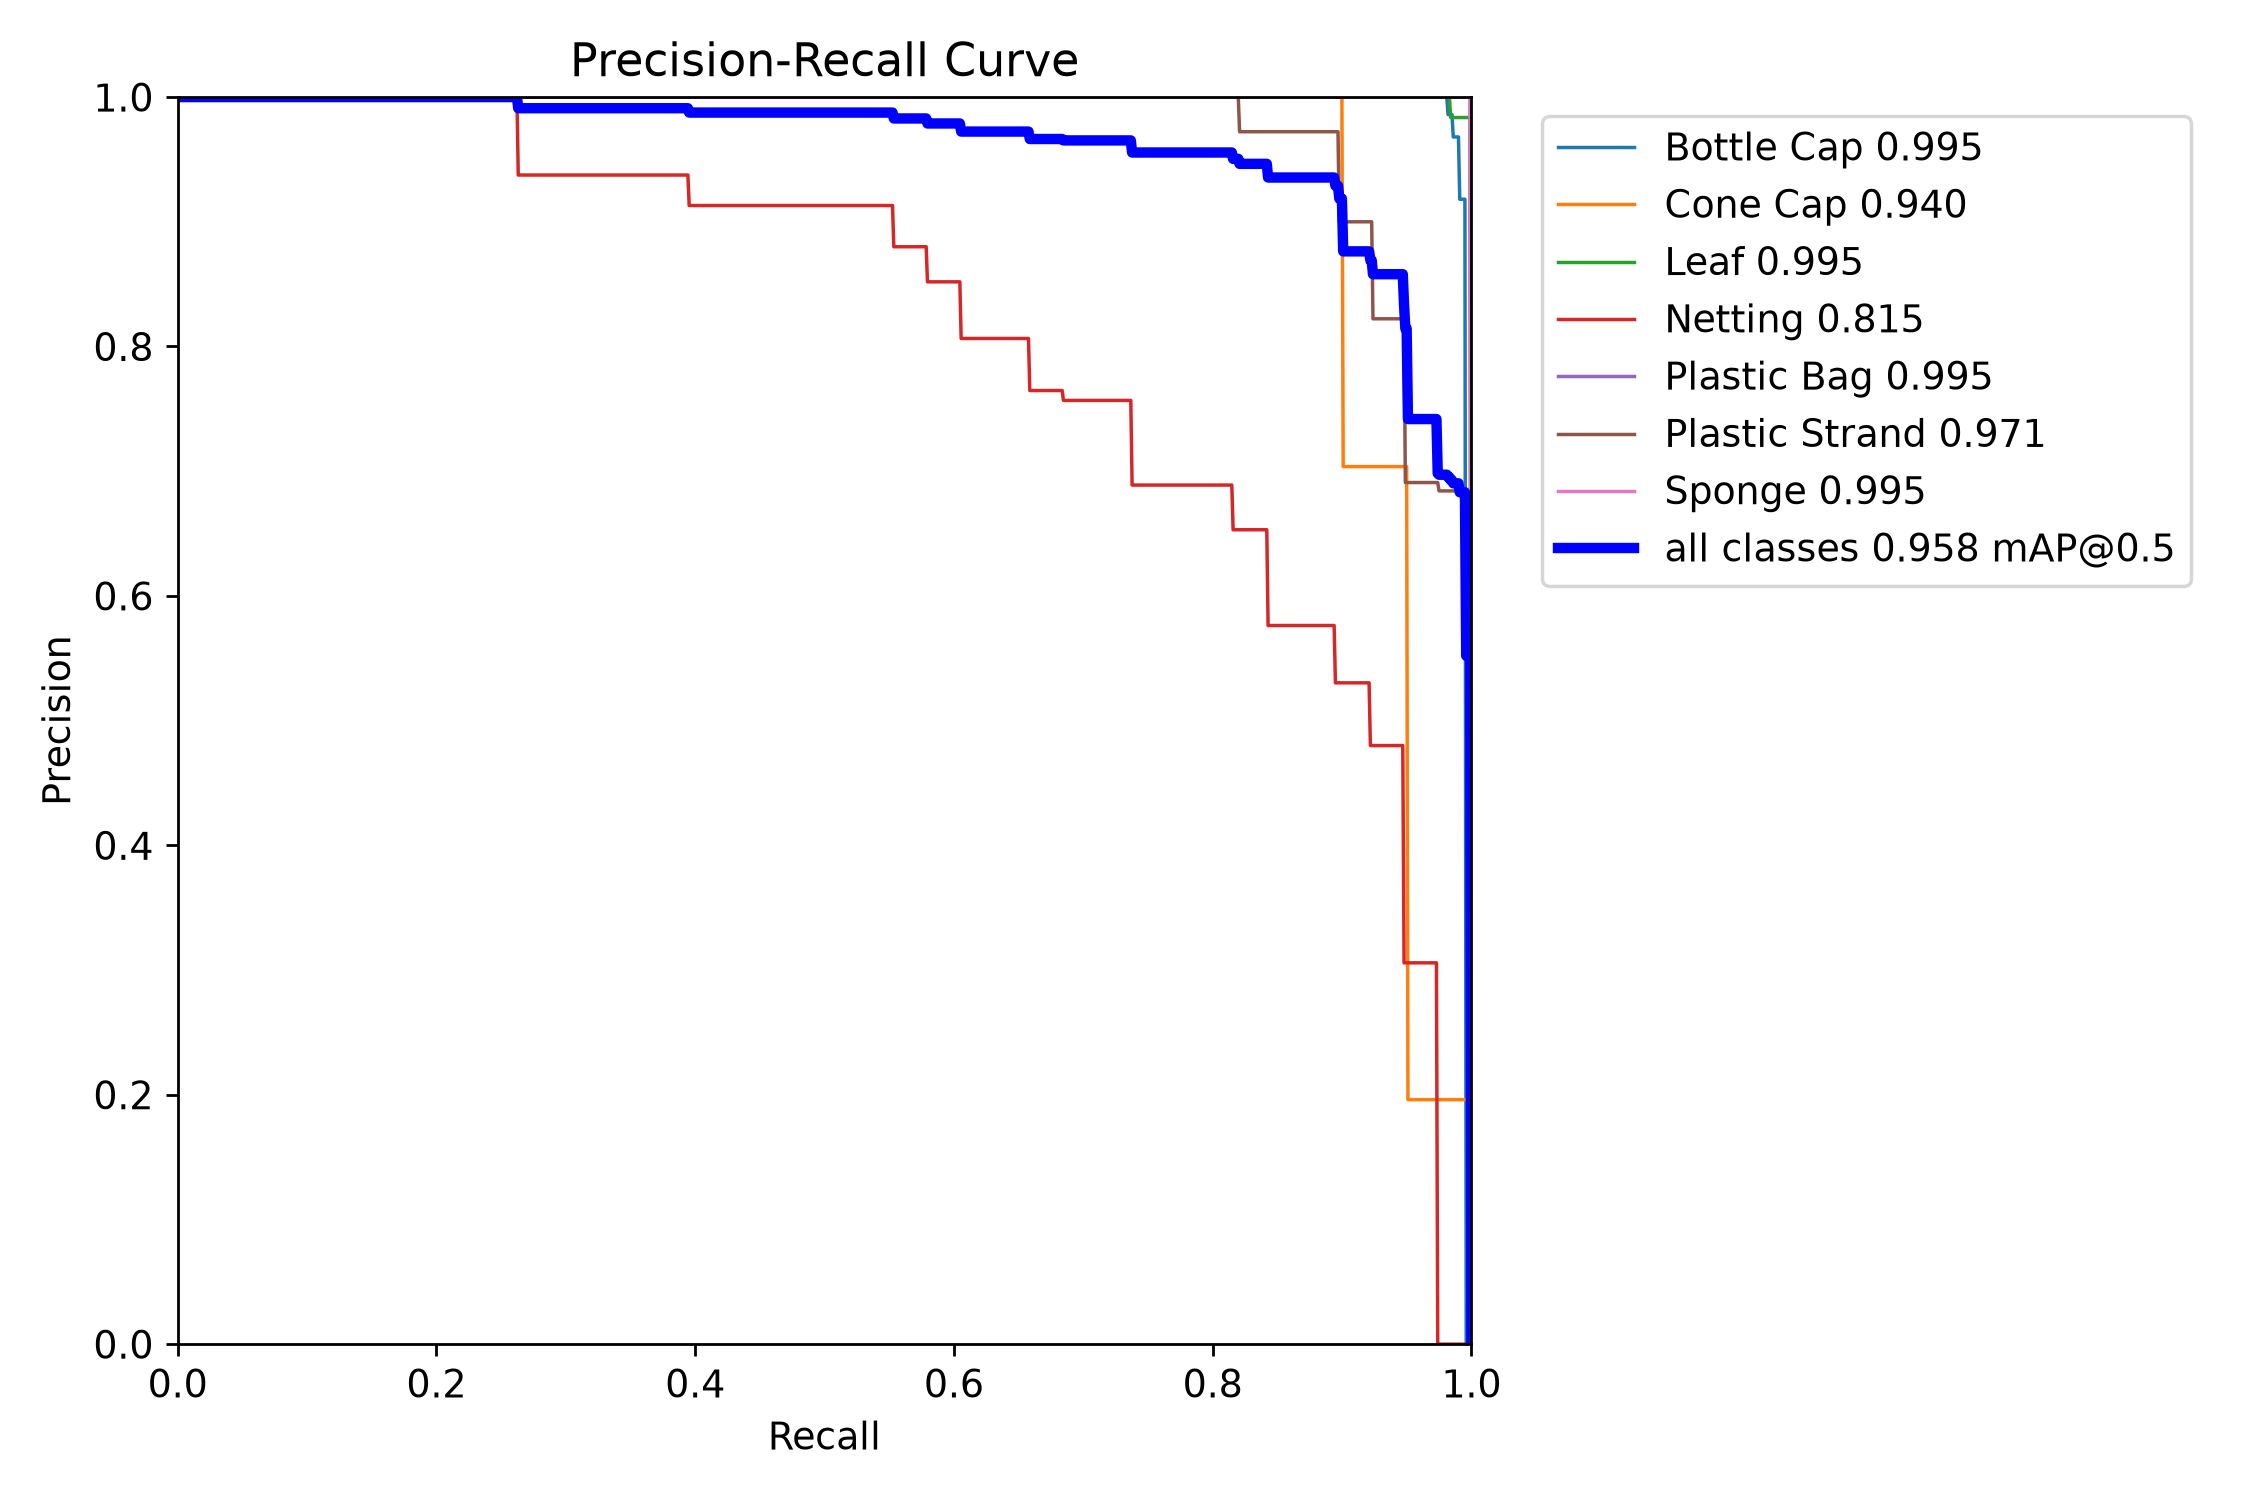

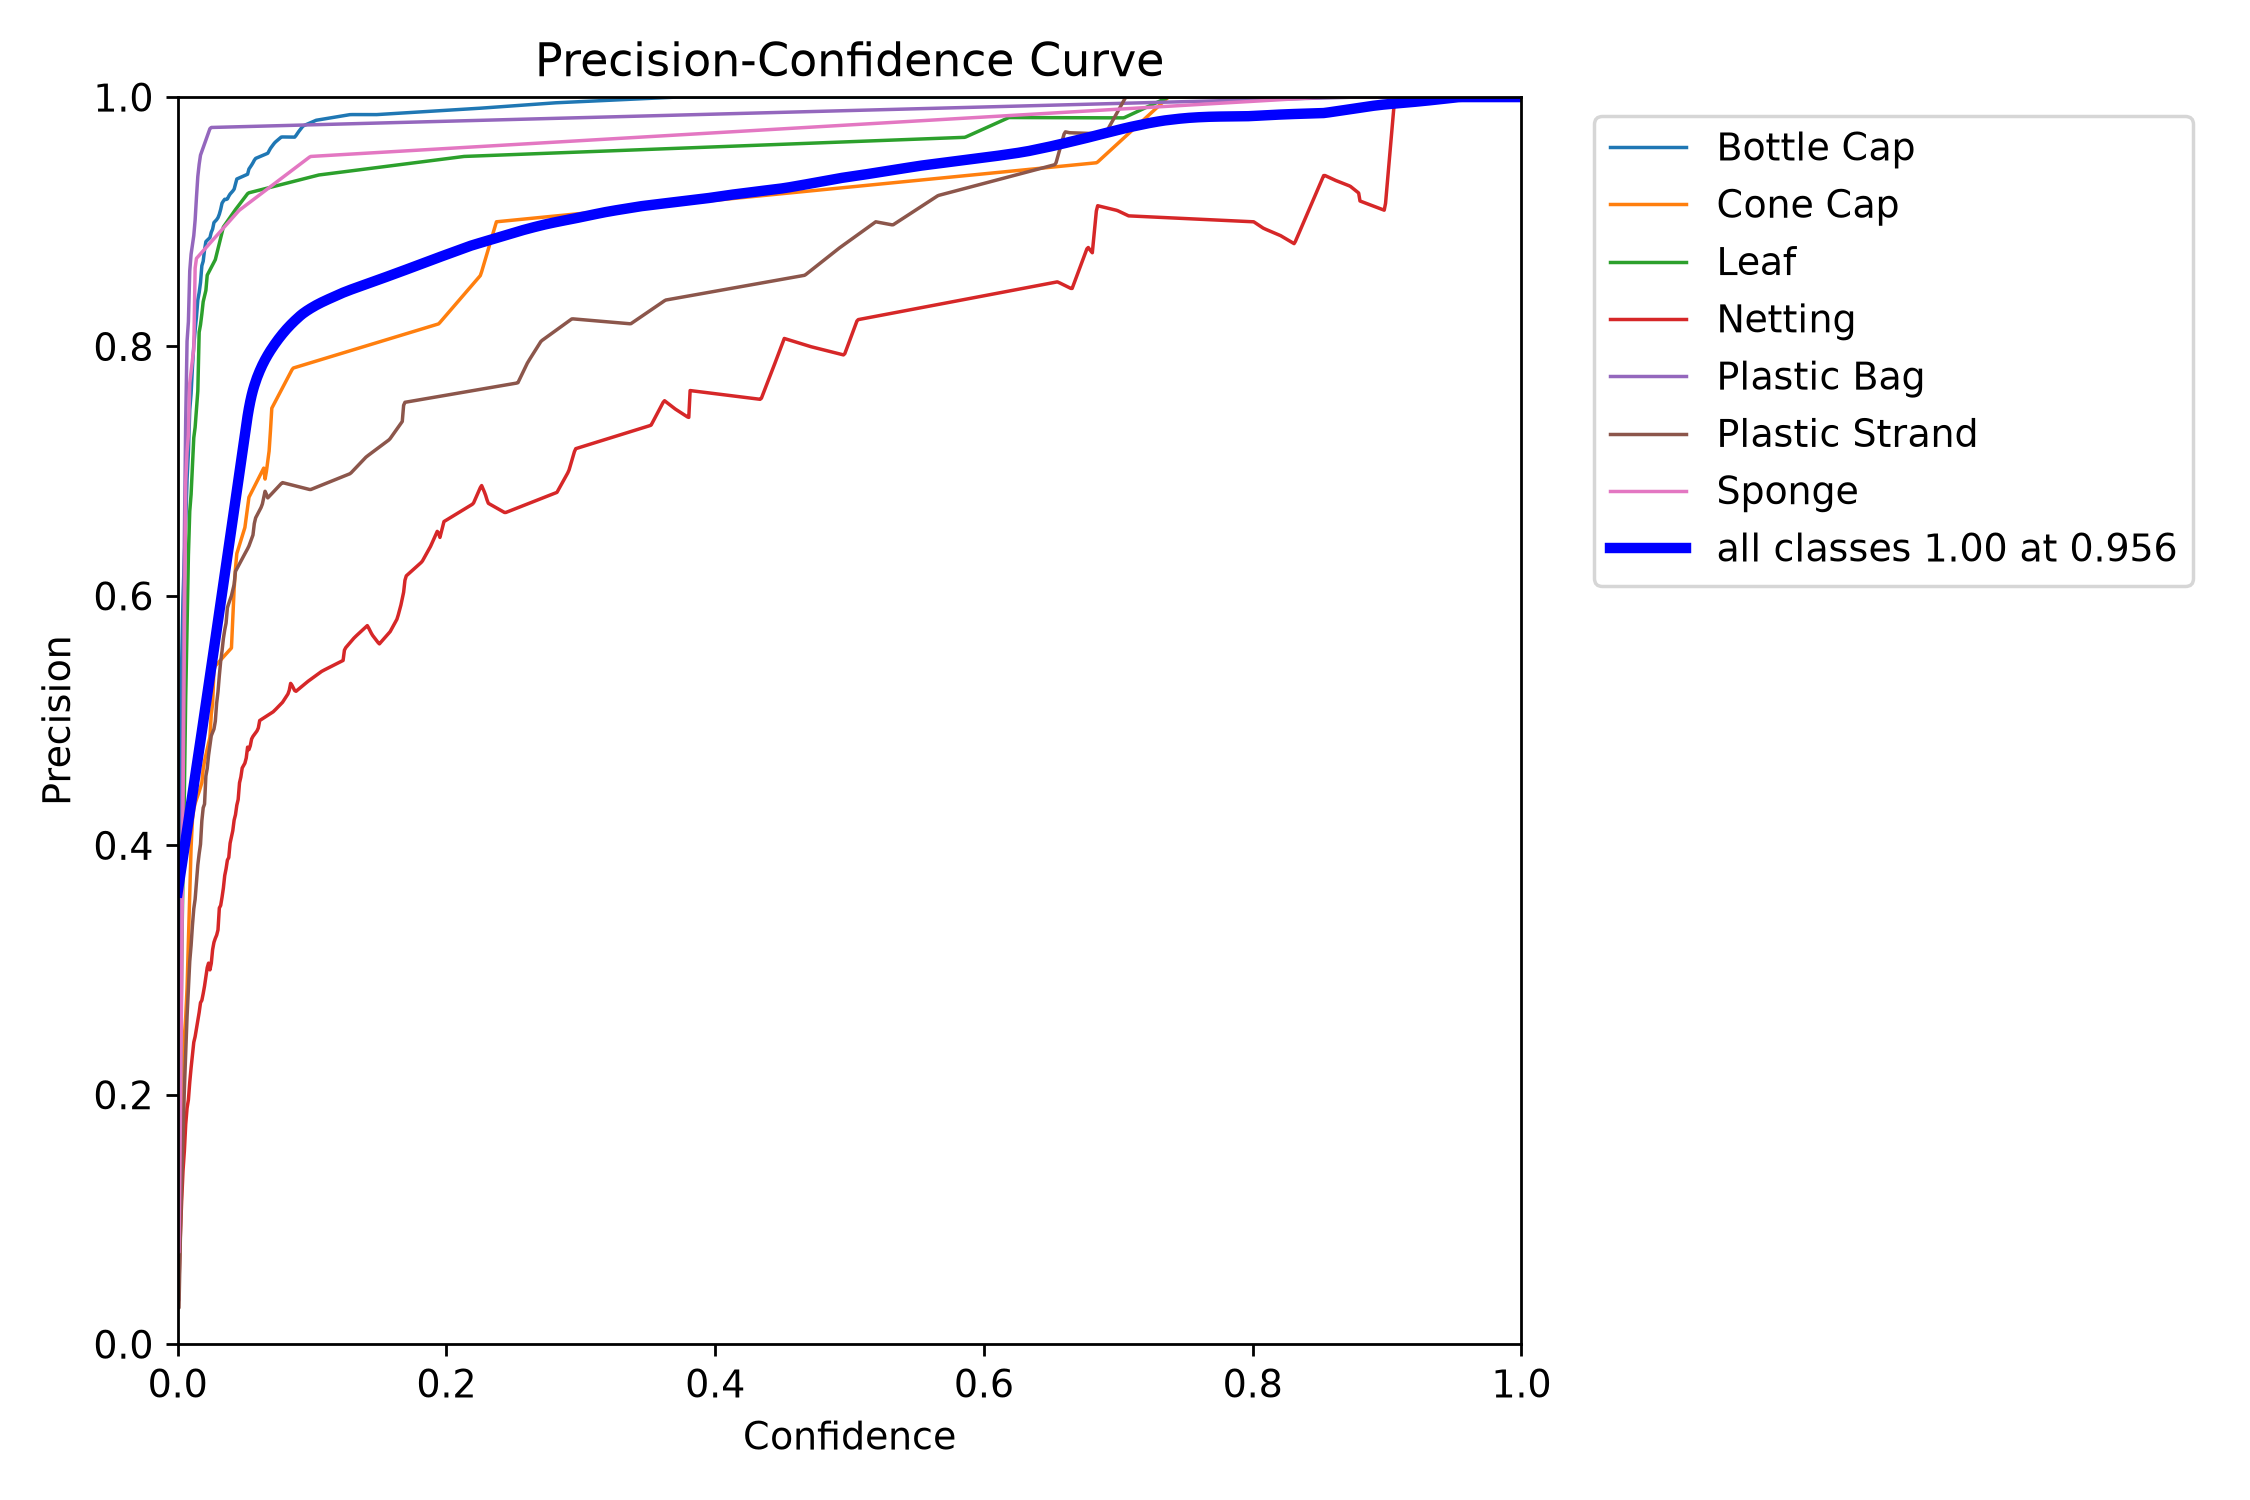

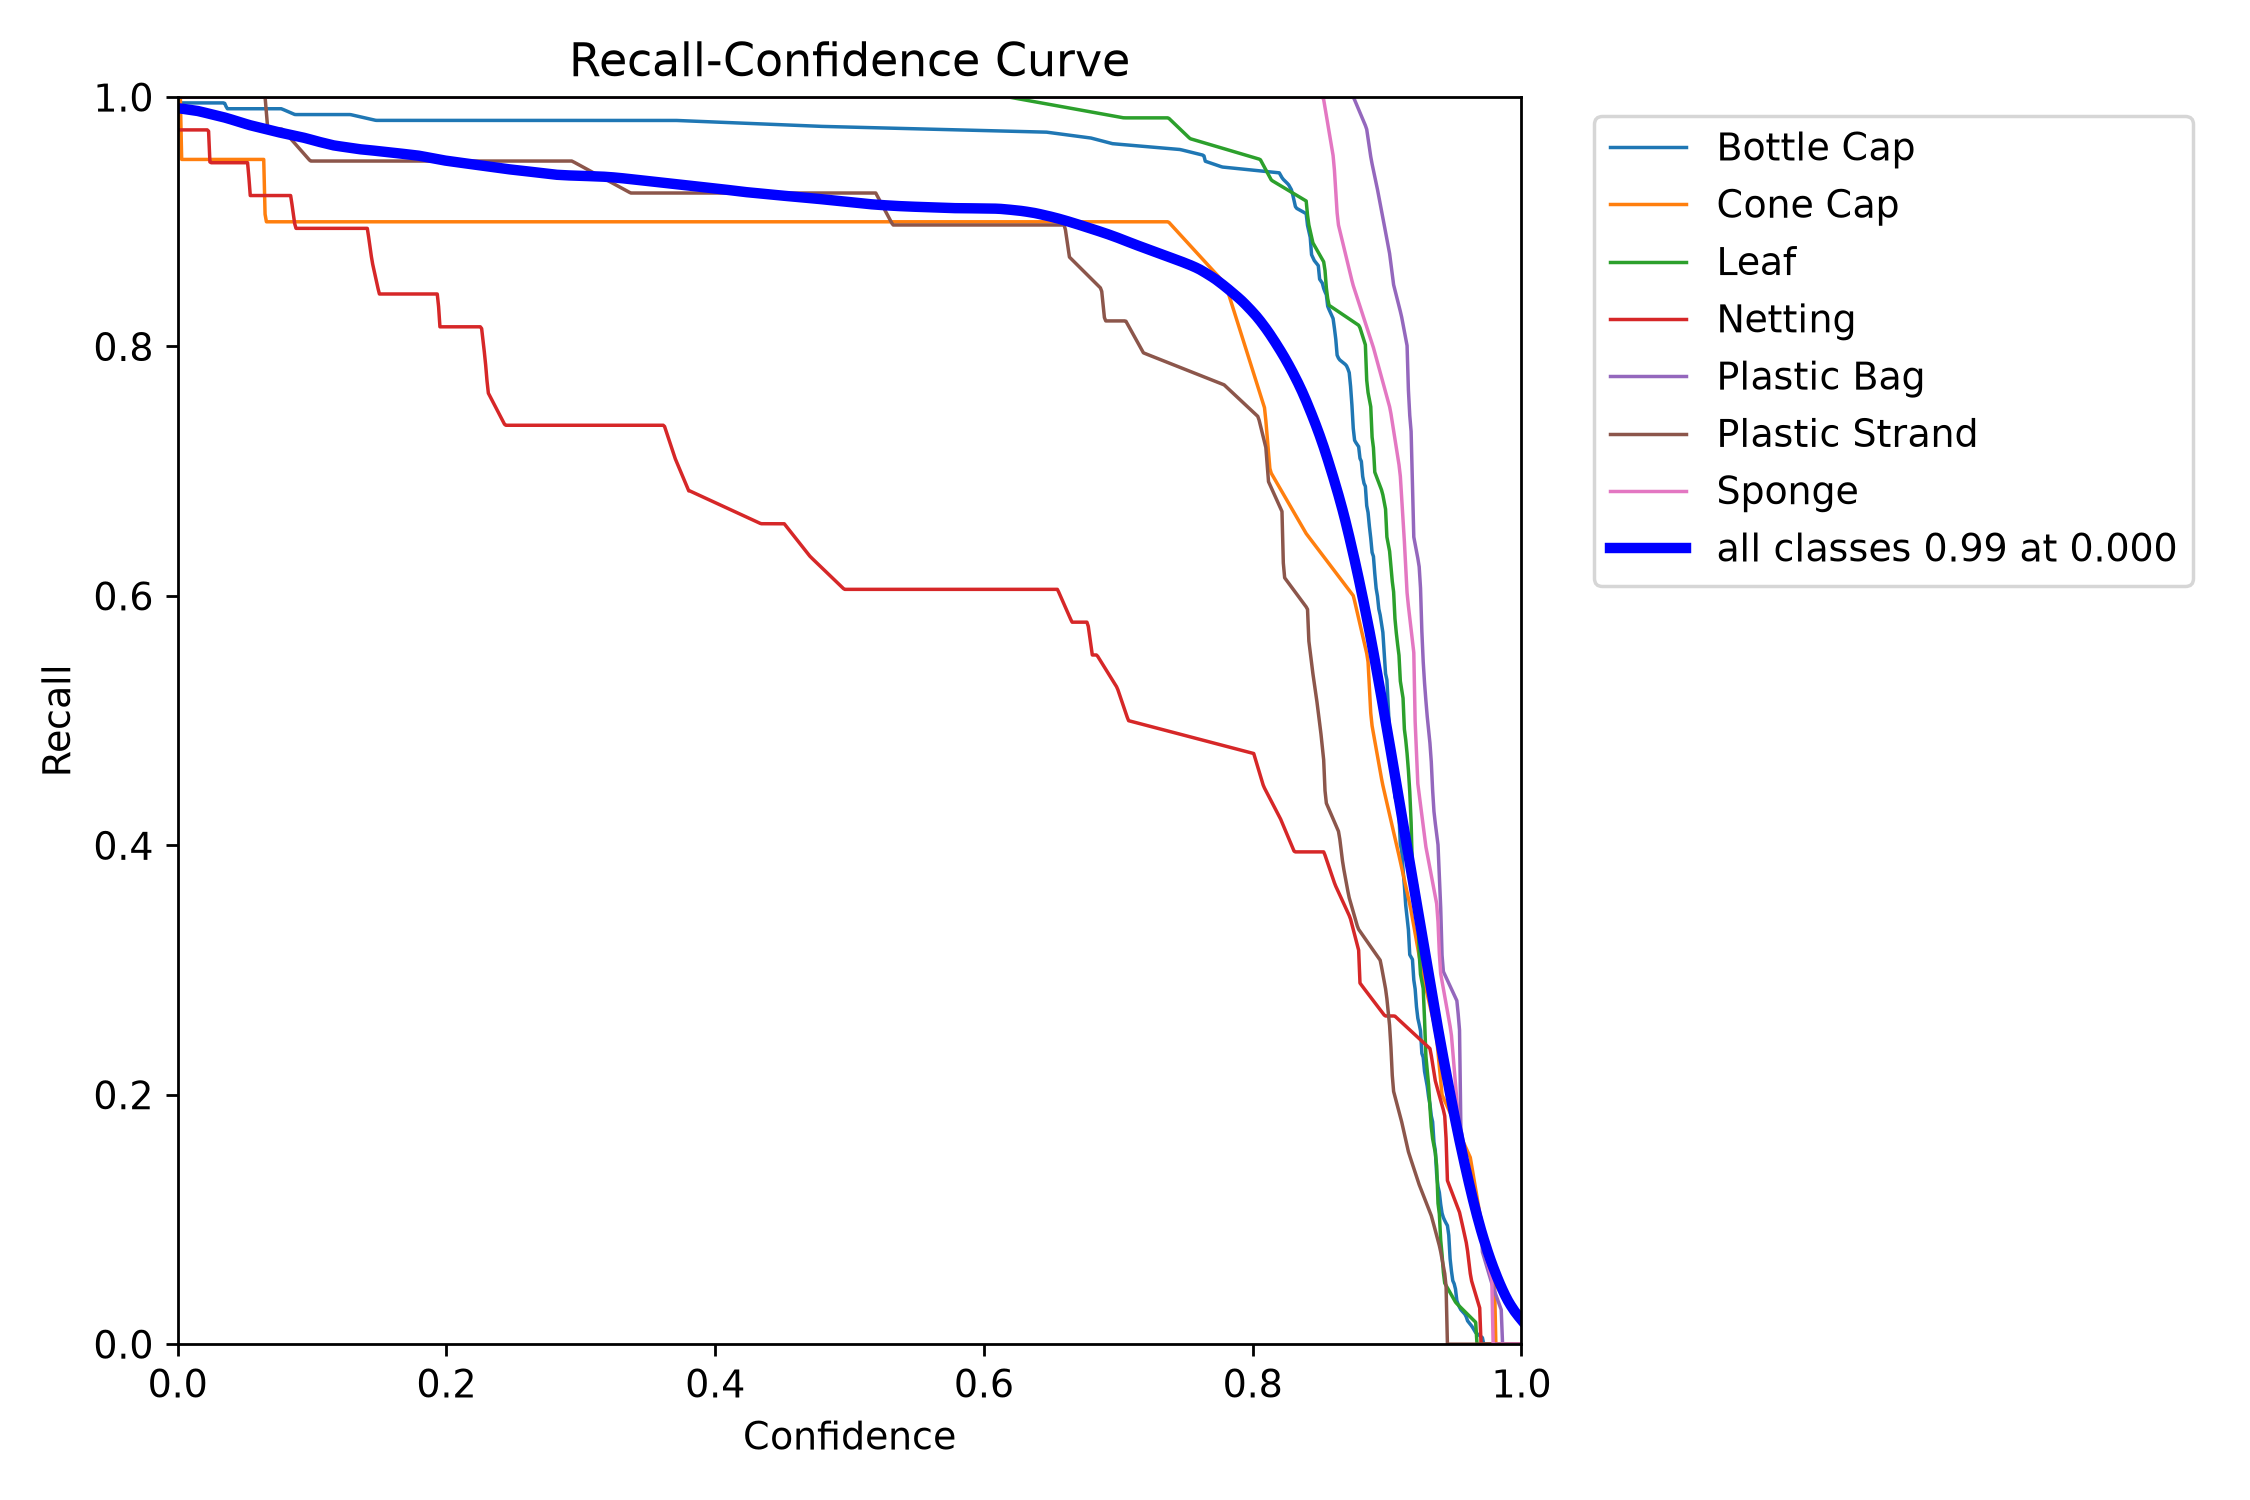

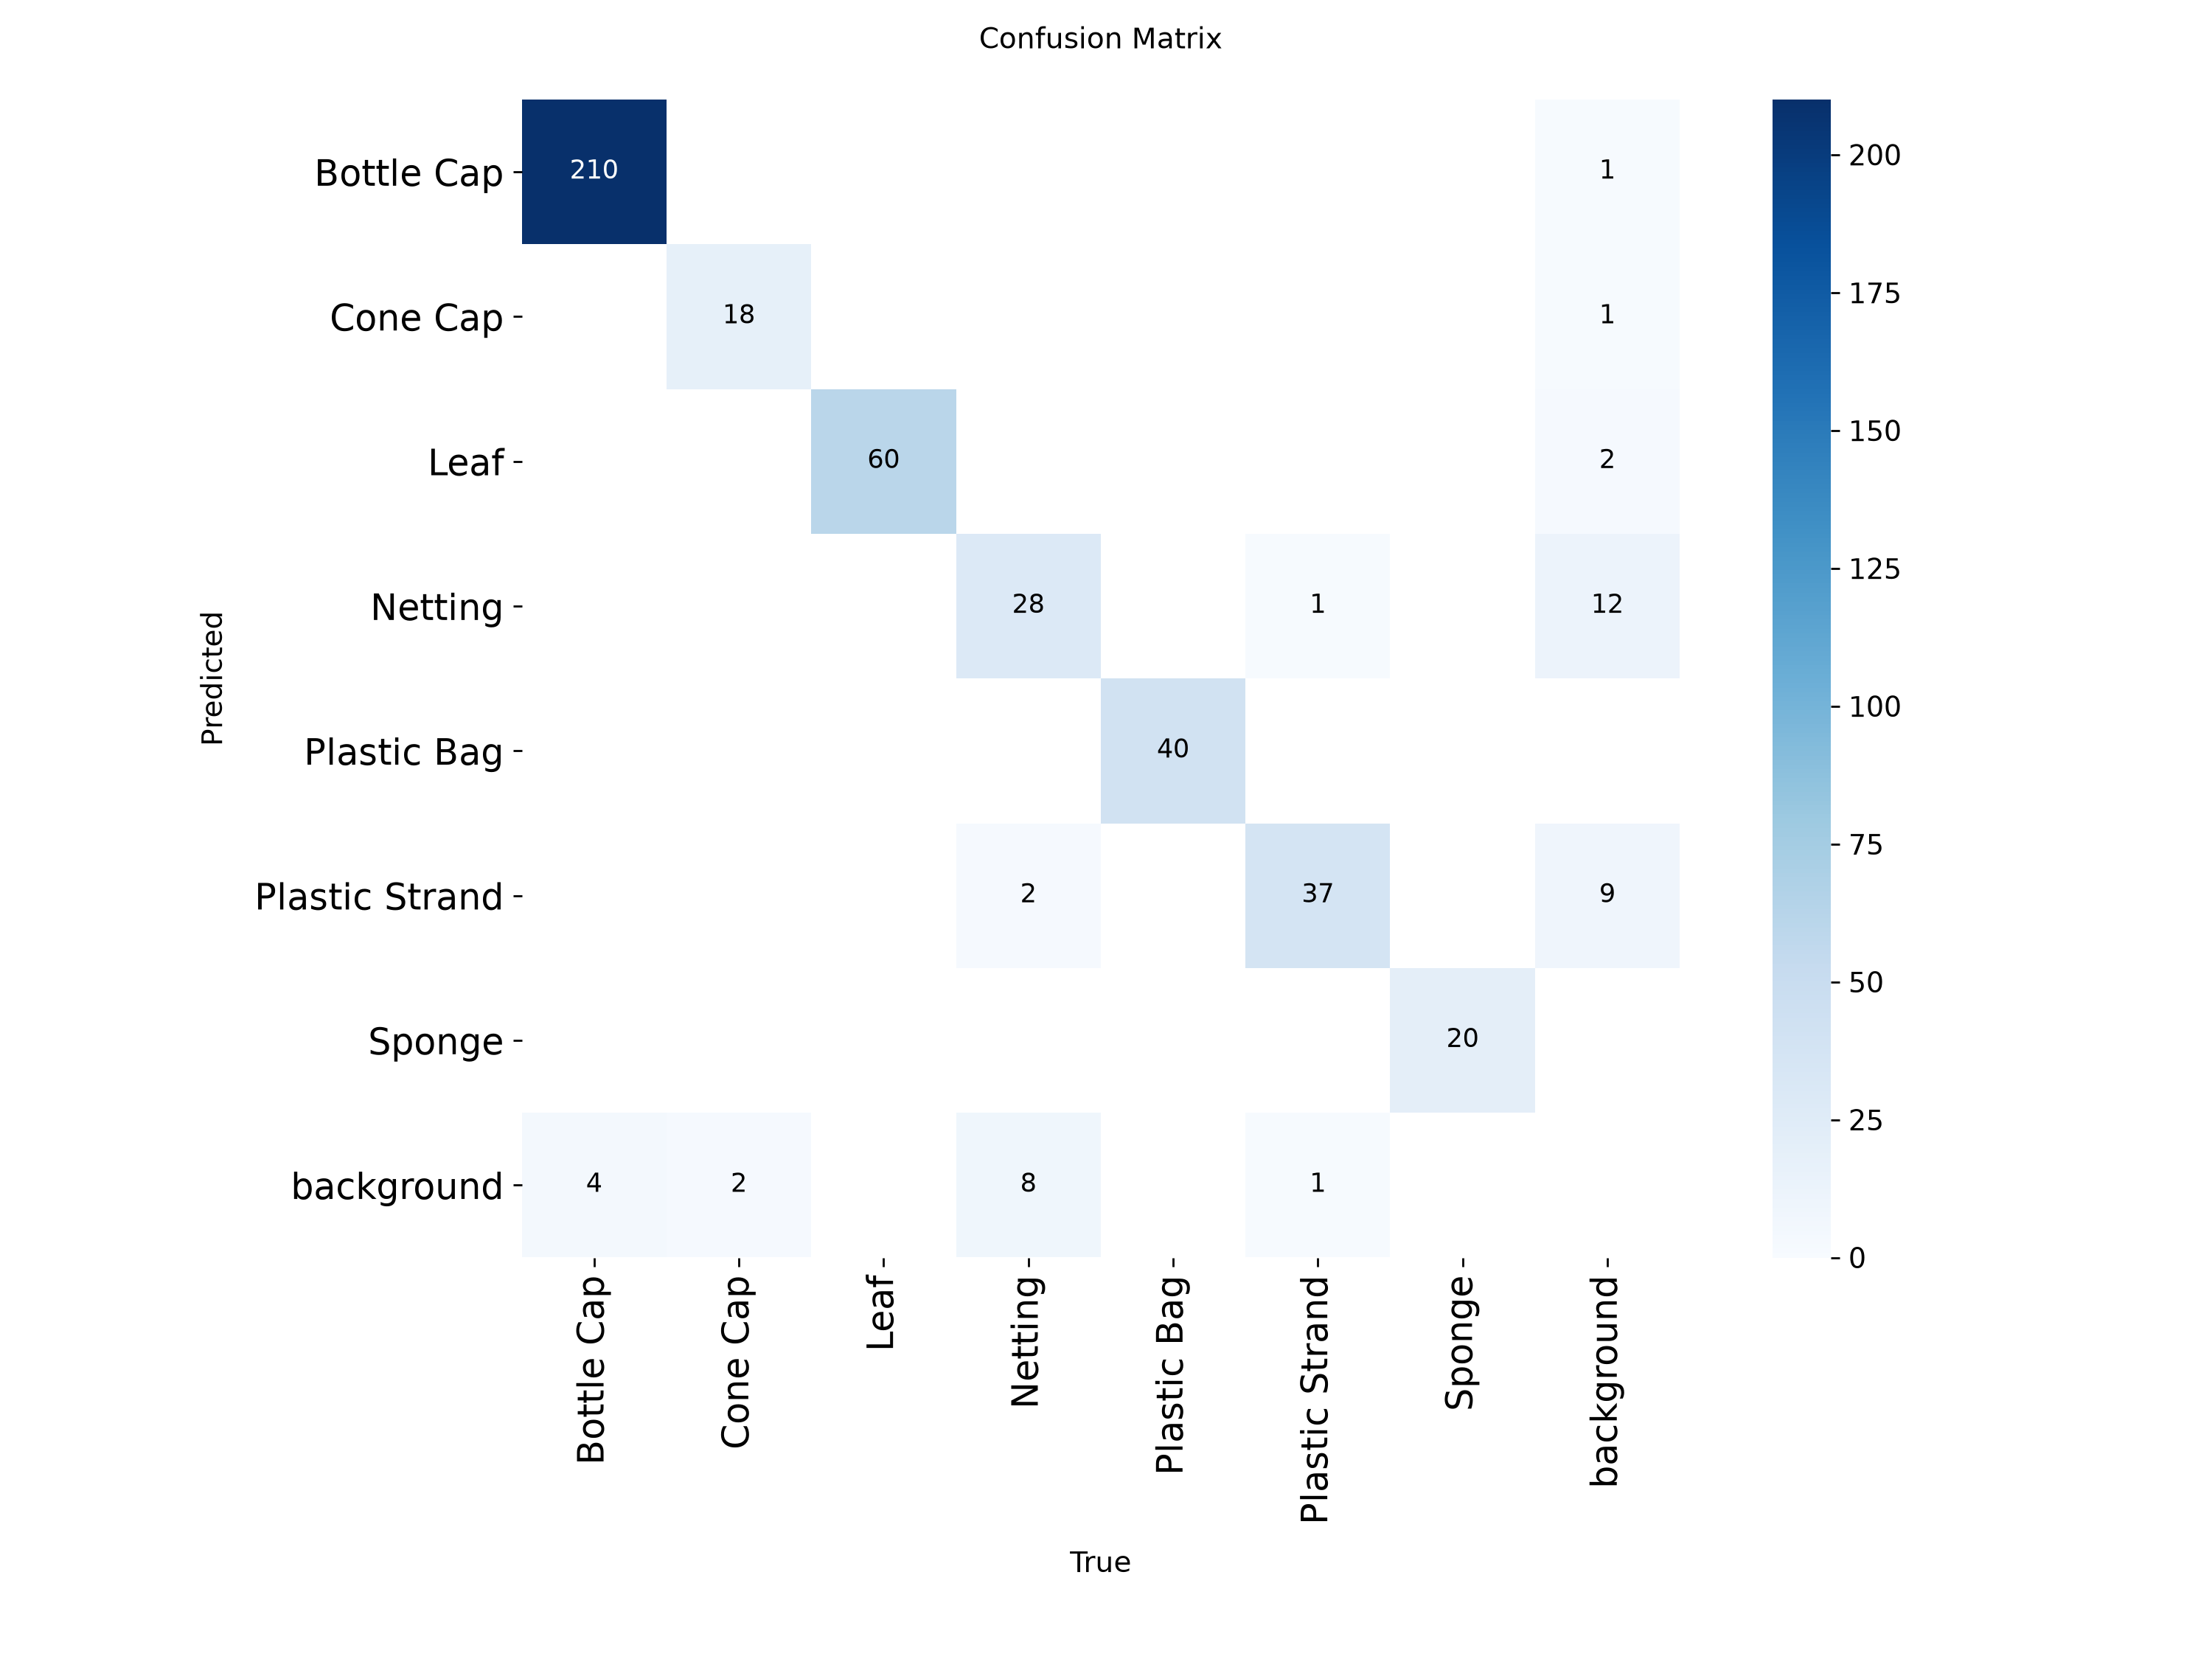

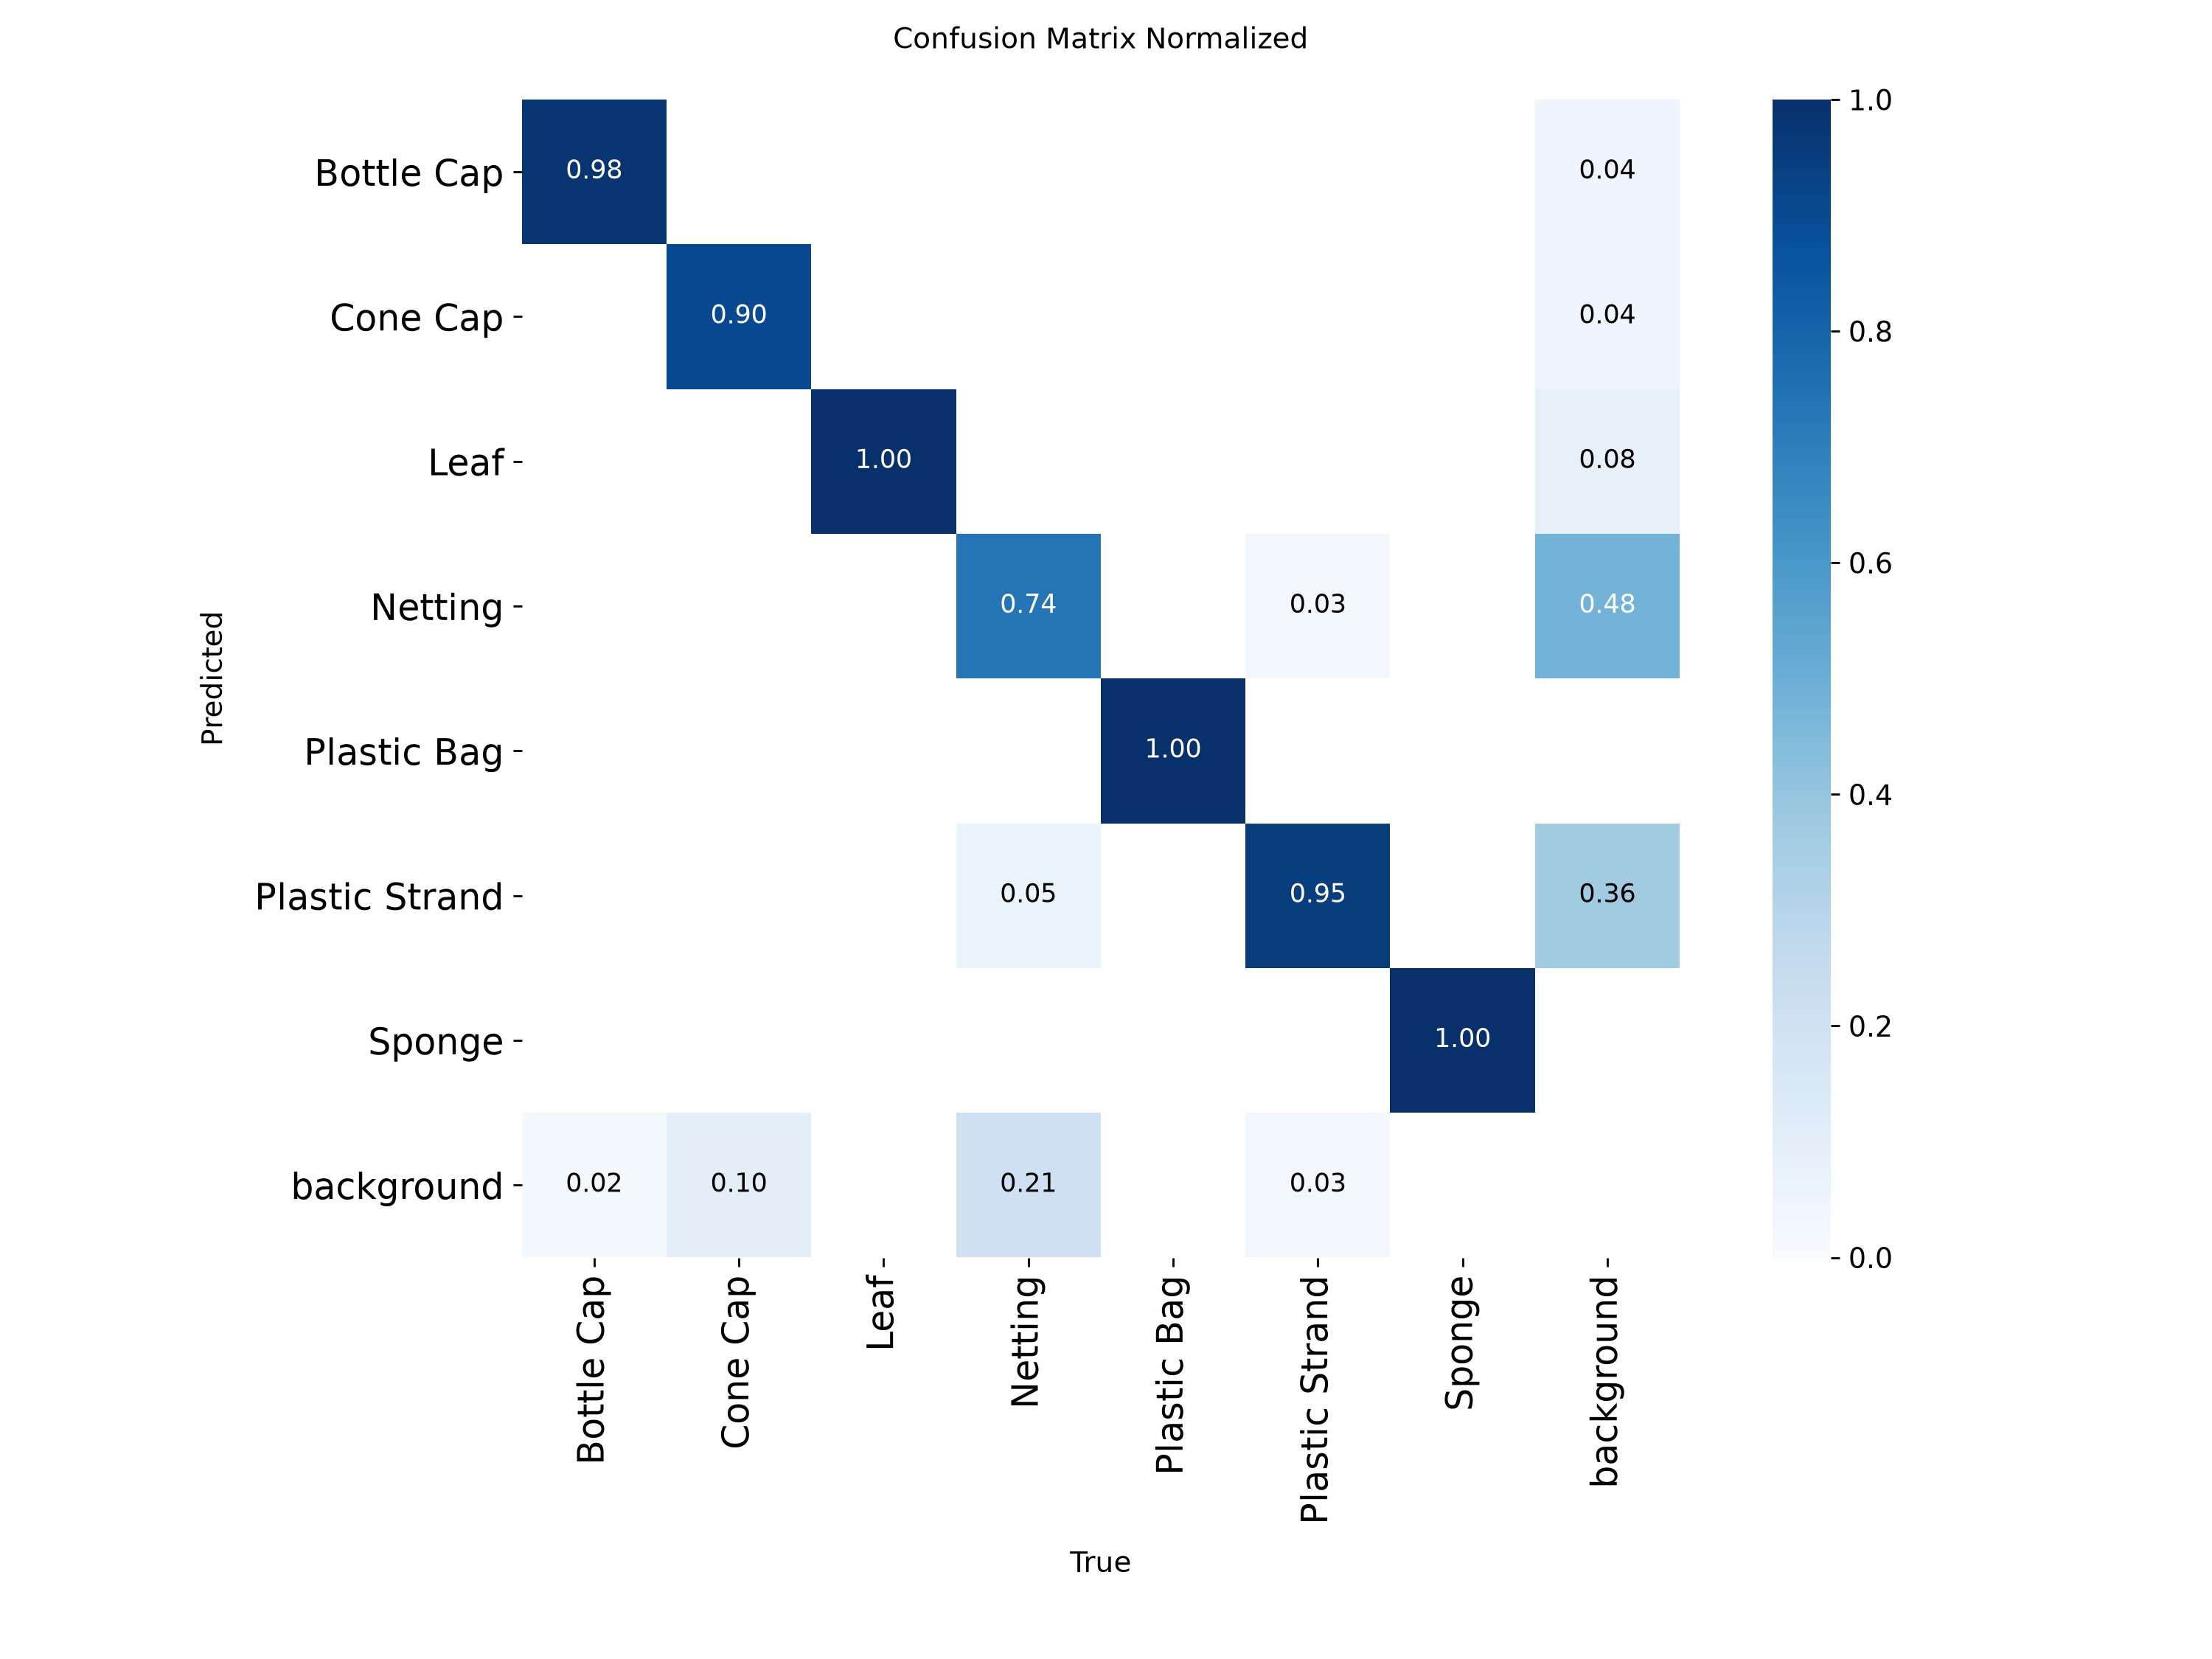

In [14]:
from IPython.display import Image, display
import os

# Set the base directory
base_dir =  'runs/detect/train'

# List of filenames to display
filenames = [
    "labels.jpg",
    "BoxF1_curve.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]

# Display each image
for filename in filenames:
    image_path = os.path.join(base_dir, filename)
    display(Image(image_path))

## 🔎 Running an Inference
* <font color = "FFC067">Test real-world application</font> for the model
  
Configure the two inference parameters as needed: `conf` and `iou`
  * <font color = "FFC067">Confidence Threshold</font> (conf):
    * Sets minimum probability score required for <font color = "FFC067">keeping detections</font>  and predicted bounding box
    * Adjust appropriately to reduce either low-confidence guesses or false positives
  * <font color = "FFC067">Intersection over Union Threshold</font> (iou):
    * Sets Non-Maximum Suppression (NMS) value required for <font color = "FFC067">removing duplicates</font> and overlapping bounding boxes
    * Adjust appropriately to control the strength of merging and deleting neighboring duplicate detections

In [15]:
# Download the video to test the model

!wget https://huggingface.co/datasets/OceanCV/PlasticTank_Video/resolve/main/tankvid.mp4?download=true -O tankvid.mp4

--2026-09-03 15:28:14--  https://huggingface.co/datasets/OceanCV/PlasticTank_Video/resolve/main/tankvid.mp4?download=true
Resolving huggingface.co (huggingface.co)... 13.35.196.21, 13.35.196.43, 13.35.196.68, ...
Connecting to huggingface.co (huggingface.co)|13.35.196.21|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/679165f3883d5d3ca04ae560/2c783fe000b5bb9d768e4994761d8fb9d1e5d181f5239d5c2aee034a70b824bd?X-Xet-Cas-Uid=public&response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27tankvid.mp4%3B+filename%3D%22tankvid.mp4%22%3B&response-content-type=video%2Fmp4&user_id=public&Expires=1788467294&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjc5MTY1ZjM4ODNkNWQzY2EwNGFlNTYwLzJjNzgzZmUwMDBiNWJiOWQ3NjhlNDk5NDc2MWQ4ZmI5ZDFlNWQxODFmNTIzOWQ1YzJhZWUwMzRhNzBiODI0YmRcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPWF0dGFjaG1lbnQlM0IrZmlsZW5hbWUlMkE

In [ ]:
from ultralytics import YOLO

model_path = os.path.join(base_dir, 'weights/best.pt')
model = YOLO(model_path)

video_path = 'tankvid.mp4'

results = model.track(source=video_path, save=True, show=True, conf=0.25, iou=0.7)